In [8]:
# Célula Nova: Top 5 Indicadores de Phishing (Ajustado)

# 1. Identificar automaticamente qual é a coluna Target (a última coluna do dataset)
target_col = df.columns[-1]

# 2. Calcular a correlação ignorando a coluna 'Index' ou 'id' se existir
df_numeric = df.select_dtypes(include=['number'])
if 'Index' in df_numeric.columns:
    df_numeric = df_numeric.drop(columns=['Index'])
if 'id' in df_numeric.columns:
    df_numeric = df_numeric.drop(columns=['id'])

corr = df_numeric.corr()[target_col].drop(target_col)

# 3. Obter os Top 5
top_phishing = corr.sort_values(ascending=False).head(5)
top_legit = corr.sort_values().head(5)

print(f"🎯 Coluna Target detetada: '{target_col}'\n")
print("⚠️ Top 5 Atributos mais associados a Phishing:")
print(top_phishing)

print("\n✅ Top 5 Atributos mais associados a Sites Legítimos:")
print(top_legit)

🎯 Coluna Target detetada: 'class'

⚠️ Top 5 Atributos mais associados a Phishing:
HTTPS             0.714704
AnchorURL         0.692895
PrefixSuffix-     0.348588
WebsiteTraffic    0.346003
SubDomains        0.298231
Name: class, dtype: float64

✅ Top 5 Atributos mais associados a Sites Legítimos:
DomainRegLen     -0.225879
ShortURL         -0.067931
AbnormalURL      -0.060751
HTTPSDomainURL   -0.040096
Redirecting//    -0.038885
Name: class, dtype: float64


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Carregar os dados
df = pd.read_csv('../../data/phishing.csv')

# Identificar a coluna alvo (assumindo que é a última coluna)
target_col = df.columns[-1]

# Gerar o gráfico de pizza
plt.figure(figsize=(6, 6))
df[target_col].value_counts().plot.pie(
    autopct='%1.1f%%', 
    colors=['#4CAF50', '#FF5722'], 
    startangle=90, 
    labels=['Legítimo', 'Phishing']
)
plt.title('Distribuição da Variável Alvo (Phishing vs Legítimo)')
plt.ylabel('')
plt.show()


In [ ]:
import seaborn as sns

# Calcular a matriz de correlação
plt.figure(figsize=(12, 8))
correlation_matrix = df.corr()

# Desenhar o Heatmap
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', linewidths=0.5)
plt.title('Matriz de Correlação das Features')
plt.show()

=== 1. BUSINESS UNDERSTANDING ===
Objetivo de Negócio: Detetar URLs de Phishing para mitigar ataques de cibersegurança.
Métrica Principal: Maximizar o Recall/F1-Score para reduzir Falsos Negativos (evitar que um site malicioso passe por legítimo).

=== 2. DATA UNDERSTANDING & EDA ===
Informações do Dataset:
<class 'pandas.DataFrame'>
RangeIndex: 11054 entries, 0 to 11053
Data columns (total 32 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   Index                11054 non-null  int64
 1   UsingIP              11054 non-null  int64
 2   LongURL              11054 non-null  int64
 3   ShortURL             11054 non-null  int64
 4   Symbol@              11054 non-null  int64
 5   Redirecting//        11054 non-null  int64
 6   PrefixSuffix-        11054 non-null  int64
 7   SubDomains           11054 non-null  int64
 8   HTTPS                11054 non-null  int64
 9   DomainRegLen         11054 non-null  int64
 10  Favicon     

C:\Users\rafae\AppData\Local\Temp\ipykernel_30904\1189791921.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=target_col, data=df, palette='viridis')


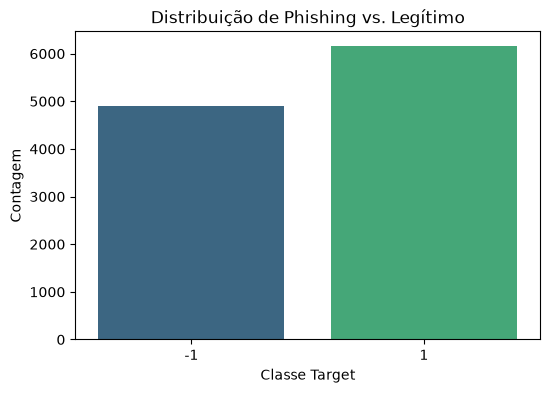

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("=== 1. BUSINESS UNDERSTANDING ===")
print("Objetivo de Negócio: Detetar URLs de Phishing para mitigar ataques de cibersegurança.")
print("Métrica Principal: Maximizar o Recall/F1-Score para reduzir Falsos Negativos (evitar que um site malicioso passe por legítimo).\n")

print("=== 2. DATA UNDERSTANDING & EDA ===")
# Carregar dados brutos
df = pd.read_csv('../../data/phishing.csv')

# Exibir informações gerais do dataset
print("Informações do Dataset:")
print(df.info())

print("\nEstatísticas Descritivas:")
print(df.describe())

# Análise da Variável Alvo
target_col = df.columns[-1]
print(f"\nDistribuição da Variável Alvo ('{target_col}'):")
print(df[target_col].value_counts(normalize=True) * 100)

# Gráfico de Distribuição da Classe Target
plt.figure(figsize=(6,4))
sns.countplot(x=target_col, data=df, palette='viridis')
plt.title('Distribuição de Phishing vs. Legítimo')
plt.xlabel('Classe Target')
plt.ylabel('Contagem')
plt.savefig('../../reports/target_distribution.png')
plt.show()

In [5]:
# Célula Nova: Auditoria de Dados
print("--- Dimensão do Dataset ---")
print(f"Linhas: {df.shape[0]} | Colunas: {df.shape[1]}\n")

print("--- Verificação de Valores Nulos ---")
print(df.isnull().sum().sum(), "valores nulos encontrados.")

print("\n--- Tipos de Dados ---")
print(df.dtypes.value_counts())

--- Dimensão do Dataset ---
Linhas: 11054 | Colunas: 32

--- Verificação de Valores Nulos ---
0 valores nulos encontrados.

--- Tipos de Dados ---
int64    32
Name: count, dtype: int64


In [4]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Caminho para o dataset (subindo duas pastas a partir de 2_exploratory_data_analysis)
df = pd.read_csv('../../data/phishing.csv')

# Visualizar as primeiras linhas
df.head()

,Index,UsingIP,LongURL,ShortURL,Symbol@,Redirecting//,PrefixSuffix-,SubDomains,HTTPS,DomainRegLen,...,UsingPopupWindow,IframeRedirection,AgeofDomain,DNSRecording,WebsiteTraffic,PageRank,GoogleIndex,LinksPointingToPage,StatsReport,class
0,0,1,1,1,1,1,-1,0,1,-1,...,1,1,-1,-1,0,-1,1,1,1,-1
1,1,1,0,1,1,1,-1,-1,-1,-1,...,1,1,1,-1,1,-1,1,0,-1,-1
2,2,1,0,1,1,1,-1,-1,-1,1,...,1,1,-1,-1,1,-1,1,-1,1,-1
3,3,1,0,-1,1,1,-1,1,1,-1,...,-1,1,-1,-1,0,-1,1,1,1,1
4,4,-1,0,-1,1,-1,-1,1,1,-1,...,1,1,1,1,1,-1,1,-1,-1,1
